In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load Dataset
data = pd.read_csv("bank-full.csv", sep=";")

print("Dataset Shape:", data.shape)

print("\nFirst 5 Rows:")
display(data.head())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nTarget Distribution:")
print(data["y"].value_counts())


Dataset Shape: (45211, 17)

First 5 Rows:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Target Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64


Features shape: (45211, 16)
Target shape: (45211,)

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Training samples: 36168
Testing samples: 9043

Model training completed successfully!

       MODEL PERFORMANCE
Accuracy  : 0.8457
Precision : 0.4182
Recall    : 0.8147
F1 Score  : 0.5527
ROC-AUC   : 0.9079

Classification Report:
              precision    recall  f1-score   support

          No       0.97      0.85      0.91      7985
         Yes       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043


Confusion Matrix:
[[6786 1199]
 [ 196  862]]


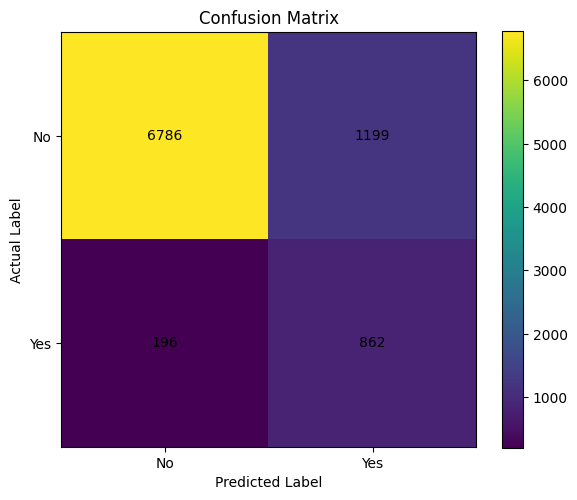

In [2]:
# 1. Separate Features and Target
# ==========================================

X = data.drop("y", axis=1)

y = data["y"].map({
    "no": 0,
    "yes": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)


# ==========================================
# 2. Identify Numerical and Categorical Data
# ==========================================

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


# ==========================================
# 3. Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ==========================================
# 4. Data Preprocessing
# ==========================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            StandardScaler(),
            numerical_features
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)


# ==========================================
# 5. Logistic Regression Model
# ==========================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


# ==========================================
# 6. Train the Model
# ==========================================

model.fit(X_train, y_train)

print("\nModel training completed successfully!")


# ==========================================
# 7. Predictions
# ==========================================

y_pred = model.predict(X_test)

y_probability = model.predict_proba(
    X_test
)[:, 1]


# ==========================================
# 8. Model Evaluation
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)


print("\n================================")
print("       MODEL PERFORMANCE")
print("================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ==========================================
# 9. Classification Report
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No", "Yes"]
    )
)


# ==========================================
# 10. Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 11. Display Confusion Matrix
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["No", "Yes"]
)

plt.yticks(
    [0, 1],
    ["No", "Yes"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()